## Behavioral Analysis: Day 2 - Sociability 

This notebook processes EthoVision output files from the three-chamber social interaction paradigm to quantify **sociability** in Alzheimer's Disease (AD) mice and control mice. The analysis focuses on **Day 2** of the experiment, where one cup contains a mouse (social stimulus) and the other cup is empty (non-social stimulus). 

This notebook focuses on **Day 2 sociability** behavioral discrimination index, which was calculated as follows:

$SI = \frac{t_{social} - t_{non-social}}{t_{social} + t_{non-social}}$

where $t_{social}$ is the time spent investigating the social stimulus, which is another mouse, and $t_{non-social}$ is the time spent investigating the non-social stimulus, which is an empty cup. 

Values: 
- **Above 0**: Preference for social stimulus
- **Below 0**: Preference for non-social stimulus
- **0**: No preference 

The following steps are taken to get the sociability index for the different groups (3xTg males, 3xTg females, Ntg control males, Ntg control females):
1. For each Excel file (EthoVision output files, corresponding to a specific mouse): 
    * Metadata is read 
    * Animal ID, genotype, sex, batch, and the side on which the stimulus mouse was placed is identified 
2. Identify relevant time periods in excel sheets  (each sheet contains periods of investigation in regions of interest)
    * Calculate how much time each animal spent with its nose-point in 
        * the left and right cup zones,
        * surrounding cup zones, and 
        * chamber zones
3. Sum up the investigation time periods 
    * Convert measurements into time spent investigating with mouse cup and time spent investigating without mouse cup 
4. Visualize sociability measures 
5. Calculate a discrimination index for each mouse
6. Find the average discrimination index for each group 
7. Visualize findings 
8. Perform statistical analyses to find out whether the differences between groups are significant 

Next to finding the discrimination index, **total investigation time** is also calculated. 

## 0. Preparation 

### 0.1. Load all relevant libraries

In [59]:
import pandas as pd
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import math 

# Statistical testing
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

### 0.2. Define file paths

In [6]:
PROJECT_DIR = Path.cwd()
print(PROJECT_DIR)

OUTPUT_DIR = PROJECT_DIR / "Behavioral Analysis"
OUTPUT_DIR.mkdir(exist_ok=True)
print(OUTPUT_DIR)

# excel sheets
DATA_DIR = PROJECT_DIR / "excel files/day 2"
print(DATA_DIR)


/Users/febevansommeren/Documents/EEG
/Users/febevansommeren/Documents/EEG/Behavioral Analysis
/Users/febevansommeren/Documents/EEG/excel files/day 2


### 0.3. Set some global variables  

In [7]:
OUTPUT_COLUMNS = [
    'Time spent in zone right cup',
    'Time spent in zone left cup',
    'Time spent surrounding right cup',
    'Time spent surrounding left cup',
    'Time spent in zone right chamber',
    'Time spent in zone middle chamber',
    'Time spent in zone left chamber',
    'Animal ID',
    'Animal info',
    'Genotype',
    'Sex',
    'Batch',
    'Time spent in zone with mouse',
    'Time spent in zone without mouse',
    'Time spent surrounding mouse',
    'Time spent surrounding no mouse'
]

"""
Mapping of Animal IDs to trial time boundaries
Time boundaries are from start ttl until end ttl
If not other specified, ttl ended after exactly 10  minutes (600s)
'animal_ID' : (start, end)
"""
ANIMAL_TRIAL_TIME_BOUNDARIES = { # adjusted fps
    '8989': (5, 601),
    '8993': (4, 606),
    '8982': (2, 654),
    '8995': (3, 605),
    '8990': (2, 653),
    '8903': (5, 607),
    '8998': (6, 658),
    '8981': (7, 609),
    '8987': (3, 605),
    '8988': (3, 537),
    '8996': (3, 605),
    '8994': (4, 606),
    '8983': (3, 605), 
    '8992': (4, 606),
    '8985': (4, 606),
    '8997': (4, 606),
    '9000': (5, 607),
    '9001': (3, 605),
    '9007': (4, 605),
    '9002': (5, 607),
    '9005': (6, 607),
    '9012': (3, 605),
    '9010': (3, 605),
    '9020': (3, 604),
    '9003': (3, 605),
    '8991': (5, 606), 
    '8986': (3, 604), 
    '9013': (5, 607),
    '9017': (3, 604),
    '9019': (3, 604), 
    '9009': (1, 602),
    '9008': (1, 602),
    '9004': (0, 602),
    '9018': (1, 606),
    '9014': (3, 604),
    '9016': (1, 604),
    '9011': (3, 605),
    '8858': (2, 622),
    '8760': (2, 604),
    '8851': (3, 604),
    '8859': (2, 607),
    '8857': (1, 602),
    '8854': (1, 602),
    '8855': (1, 603),
    '9015': (3, 605),
}

# Define column patterns for each zone (each excel sheet might have slightly different column names)
ZONE_COLUMNS = {
    'right_cup': [
        'In zone(Right Cup / Nose-point)',
        'In zone(right cup 2 / Nose-point)',
        'In zone(right cup 3 / Nose-point)',
        'In zone(right cup 1 / Nose-point)'
        ],
    'left_cup': [
        'In zone(Left Cup / Nose-point)',
        'In zone(left cup 2 / Nose-point)',
        'In zone(left cup 3 / Nose-point)',
        'In zone(Left Cup 1 / Nose-point)'
    ],
    'right_cup_zone': [
        'In zone(Right Cup Zone / Nose-point)',
        'In zone(right cup zone 2 / Nose-point)',
        'In zone(right cup zone 3 / Nose-point)',
        'In zone(Right Cup Zone 1 / Nose-point)'
    ],
    'left_cup_zone': [
        'In zone(Left Cup Zone / Nose-point)',
        'In zone(left cup zone 2 / Nose-point)',
        'In zone(Left cup zone 3 / Nose-point)',
        'In zone(Left Cup Zone 1 / Nose-point)'
    ],
    'right_chamber': [
        'In zone(Right Chamber / Nose-point)',
        'In zone(right chamber 2 / Nose-point)',
        'In zone(right chamber 3 / Nose-point)',
        'In zone(Right Chamber 1 / Nose-point)'
    ],
    'middle_chamber': [
        'In zone(Middle Chamber / Nose-point)',
        'In zone(middle chamber 2 / Nose-point)',
        'In zone(middle chamber 3 / Nose-point)',
        'In zone(Middle Chamber 1 / Nose-point)'
    ],
    'left_chamber': [
        'In zone(Left Chamber / Nose-point)',
        'In zone(left chamber 2 / Nose-point)',
        'In zone(left chamber 3 / Nose-point)',
        'In zone(Left Chamber 1 / Nose-point)'
    ]
}

### 0.4. Define helper functions

In [11]:
def calculate_time_in_zones(zone_keywords, trial_window, fps=30): 
    """
    Calculates the total time spent in a zone matching the given keywords during a trial window. 

    Parameters: 
    ### zone_keywords [list[str]]: Keywords used to identify the relevant zone columns in the EthoVision
        output. 
    ### trial_window [pandas.DataFrame]:  DataFrame containing the EthoVision tracking data for the relevant
        trial period. Columns should include binary zone indicators, where 1 means the animal was detected in 
        that zone during a given frame.
    ### fps [int | float]: Frames per second of the video recording. The default is 30 fps.
    Returns: 
    ### total_time [float]: Total time spent in the matching zone columns in seconds.
    """
    total_time = 0
    for keyword in zone_keywords:
        matching_cols = [col for col in trial_window.columns if keyword.lower() in col.lower()]
        if matching_cols:
            total_time += (trial_window[matching_cols] == 1).sum().sum()
    return total_time / fps  

def add_derived_measures(df):
    """
    Add sociability-related measures to the dataframe.

    This function calculates the discrimination index and total investigation
    time for each mouse based on the time spent investigating the social and
    non-social stimulus zones.

    Parameters:
    ### df [pandas.DataFrame]: DataFrame containing time spent in the zone with the mouse and
        time spent in the zone without the mouse.

    Returns:
    ### df [pandas.DataFrame]: Copy of the input dataframe with two added columns:
        'discrimination index' and 'total investigation time'.
    """
    df = df.copy()

    with_mouse = pd.to_numeric(df["Time spent in zone with mouse"], errors="coerce")
    without_mouse = pd.to_numeric(df["Time spent in zone without mouse"], errors="coerce")

    total = with_mouse + without_mouse
    df["discrimination index"] = np.where(
        total == 0,
        np.nan,
        (with_mouse - without_mouse) / total,
    )
    df["total investigation time"] = total

    return df

## 1 - 3. Process EthoVision files 

In [12]:
def process_behavioral_data(folder_path):
    """
    Process Day 2 EthoVision Excel files and extract sociability measures.

    For each valid Excel file, this function reads the metadata and tracking data,
    selects the relevant trial window, calculates time spent in predefined zones,
    and converts left/right cup measurements into time spent with and without the
    stimulus mouse.

    Parameters:
    ### folder_path [str]: Path to the folder containing the EthoVision Excel files.

    Returns:
    ### etho_3c_sociability_df [pandas.DataFrame]: Summary dataframe with metadata and 
        zone-based time measures for each mouse.
    """
    rows = []
    # Loop through all Excel files
    for filename in os.listdir(folder_path):
        if filename.endswith('.xlsx'):
            file_path = os.path.join(folder_path, filename)
            metadata_df = pd.read_excel(file_path, header=None)

            # Check if the file has enough rows before accessing specific metadata
            if metadata_df.shape[0] < 41: # B41 needs to be accessed 
                print(f"Skipping '{filename}' - metadata too short (only {metadata_df.shape[0]} rows)")
                continue 

            # Check if it is Day 2
            day_info = metadata_df.iloc[37, 1]  # B38
            if str(day_info).strip() != '2':
                print(f"Skipping '{filename}' - Day info is not '2' (got '{day_info}')")
                continue

            # Read data starting from row 43 (Excel row 42 + 1)
            trial_df = pd.read_excel(file_path, header=42, thousands=',') 
            trial_df.columns = trial_df.columns.str.strip()

            # handle missing values:
            trial_df = trial_df.fillna(0)  # Fills all NaN values with 0

            # Access 'Trial time' using column index 0 (column A)
            trial_df.iloc[:, 0] = pd.to_numeric(trial_df.iloc[:, 0], errors='coerce')
            trial_df['Trial time'] = trial_df.iloc[:, 0]  # Rename for consistent use

            # Identify animal ID
            animal_id = str(metadata_df.iloc[34, 1]).strip()  # B35

            if animal_id not in ANIMAL_TRIAL_TIME_BOUNDARIES:
                print(f"Warning: No trial time boundaries found for Animal ID '{animal_id}' in filename '{filename}'")
                continue
            
            # Define trial start and end time 
            trial_time_start, trial_time_end = ANIMAL_TRIAL_TIME_BOUNDARIES[animal_id]
            trial_window_df = trial_df[
                        (trial_df['Trial time'] >= trial_time_start) & 
                        (trial_df['Trial time'] <= trial_time_end)
                    ] 
            
            # Get time spent in zones
            right_cup = calculate_time_in_zones(ZONE_COLUMNS['right_cup'], trial_window_df)
            left_cup = calculate_time_in_zones(ZONE_COLUMNS['left_cup'], trial_window_df)
            right_cup_zone = calculate_time_in_zones(ZONE_COLUMNS['right_cup_zone'], trial_window_df)
            left_cup_zone = calculate_time_in_zones(ZONE_COLUMNS['left_cup_zone'], trial_window_df)
            right_chamber = calculate_time_in_zones(ZONE_COLUMNS['right_chamber'], trial_window_df)
            middle_chamber = calculate_time_in_zones(ZONE_COLUMNS['middle_chamber'], trial_window_df)
            left_chamber = calculate_time_in_zones(ZONE_COLUMNS['left_chamber'], trial_window_df)
            
            # Sum total surrounding times
            surrounding_right_cup = right_cup + right_cup_zone
            surrounding_left_cup = left_cup + left_cup_zone

            # Identify cup position
            cup_position = str(metadata_df.iloc[38, 1]).strip()  # B39

            # Rename to with/without mouse from cup position
            if cup_position == 'L':
                time_spent_with_mouse = left_cup
                time_spent_without_mouse = right_cup 
                surrounding_mouse = surrounding_left_cup
                surrounding_no_mouse = surrounding_right_cup
            elif cup_position == 'R':
                time_spent_with_mouse = right_cup
                time_spent_without_mouse = left_cup
                surrounding_mouse = surrounding_right_cup
                surrounding_no_mouse = surrounding_left_cup
            else:
                print(f"Invalid cup position '{cup_position}' in file '{filename}', skipping...")
                continue  # Skip if L/R unclear

            # Locate metadata
            animal_info = metadata_df.iloc[10, 1]  # B11
            genotype = metadata_df.iloc[35, 1]     # B36
            sex = metadata_df.iloc[36, 1]          # B37
            batch = metadata_df.iloc[40, 1]        # B41

            rows.append({
                'Time spent in zone right cup': right_cup,
                'Time spent in zone left cup': left_cup,
                'Time spent surrounding right cup': surrounding_right_cup,
                'Time spent surrounding left cup': surrounding_left_cup,
                'Time spent in zone right chamber': right_chamber,
                'Time spent in zone middle chamber': middle_chamber,
                'Time spent in zone left chamber': left_chamber,
                'Animal ID': animal_id,
                'Animal info': animal_info,
                'Genotype': genotype,
                'Sex': sex,
                'Batch': batch,
                'Time spent in zone with mouse': time_spent_with_mouse,
                'Time spent in zone without mouse': time_spent_without_mouse,
                'Time spent surrounding mouse': surrounding_mouse,
                'Time spent surrounding no mouse': surrounding_no_mouse
            })

    etho_3c_sociability_df = pd.DataFrame(rows, columns=OUTPUT_COLUMNS)    
    return etho_3c_sociability_df

In [13]:
def get_behavior_results(data_folder, output_folder): 
    """
    Process EthoVision files and save the Day 2 behavioral results.

    Parameters:
    ### data_folder [str]: Path to the folder containing the EthoVision Excel files.
    ### output_folder [str]: Path to the folder where the results file should be saved.

    Returns:
    ### df [pandas.DataFrame]: Summary dataframe containing Day 2 behavioral measures for each mouse.
    """
    df = process_behavioral_data(data_folder)

    # Save to Excel
    output_file = os.path.join(output_folder, 'behavior_results_day2.xlsx')
    df.to_excel(output_file, index=False)

    print(df.head())
    return df

#### Generate behavioral results dataframe

In [14]:
etho_3c_sociability_df = get_behavior_results(DATA_DIR, OUTPUT_DIR)

   Time spent in zone right cup  Time spent in zone left cup  \
0                     86.600000                   152.866667   
1                     35.700000                   124.933333   
2                    117.733333                    47.066667   
3                    120.900000                    67.466667   
4                     75.133333                   143.466667   

   Time spent surrounding right cup  Time spent surrounding left cup  \
0                        116.366667                       211.200000   
1                         72.200000                       203.133333   
2                        173.233333                       101.766667   
3                        186.966667                       117.033333   
4                        115.600000                       143.466667   

   Time spent in zone right chamber  Time spent in zone middle chamber  \
0                         43.433333                         107.400000   
1                         69.63333

## 4. Visualize sociability time measures

In [86]:
def prep_soc_measures_for_plotting(df):
    """
    Prepare sociability time measures for plotting by
    * creating a combined group label from sex and genotype,
    * converts selected time-measure columns to numeric values, and 
    * reshapes the dataframe from wide to long format.

    Parameters:
    ### df [pandas.DataFrame]: DataFrame containing sociability-related time measures and metadata.

    Returns:
    metled_group [pandas.DataFrame]: Long-format dataframe with group, measure, and time columns for plotting.
    """
    #  Combine Sex and Genotype into one column for grouping
    df['Group'] = df['Sex'].astype(str).str.capitalize() + ' ' + df['Genotype'].astype(str)

    # Ensure values are numeric
    cols_to_numeric = [
        'Time spent in zone with mouse',
        'Time spent in zone without mouse',
        'Time spent surrounding mouse',
        'Time spent surrounding no mouse'
    ]
    df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

    # Melt the DataFrame to long format
    melted_group = pd.melt(
        df,
        id_vars=['Group'],
        value_vars=cols_to_numeric,
        var_name='Measure',
        value_name='Time'
    )

    return melted_group

def create_plot_sociability_measures(dataframe, output_dir):
    """
    Creates and shows plot of sociability time measures  

    Parameters
    ### dataframe [pandas.DataFrame]: Long-format dataframe containing group labels, 
        time measures, and time values.
    ### output_dir [str]: directory for output 

    Returns:
    # None: when running the function, it will save and show the plot 

    """
    # Set plotting style
    sns.set(style="whitegrid")

    # Create the plot
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=dataframe,
        x='Group', 
        y='Time', 
        hue='Measure',
        errorbar='sd', 
        palette='Set2', 
        order=["F NTG", "F 3TG", "M NTG", "M 3TG"]
    )

    plt.title('Sociability Measures by Sex and Genotype')
    plt.ylabel('Time (seconds)')
    plt.xlabel('Group')
    plt.xticks(rotation=15)
    plt.legend(title='Measure', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    file_path_plot = os.path.join(output_dir, "sociability_day2_time_measures_by_sex_and_genotype")

    # Save and show plot
    plt.savefig(file_path_plot, format='pdf')
    plt.show()

### 4.1. Generate the plots

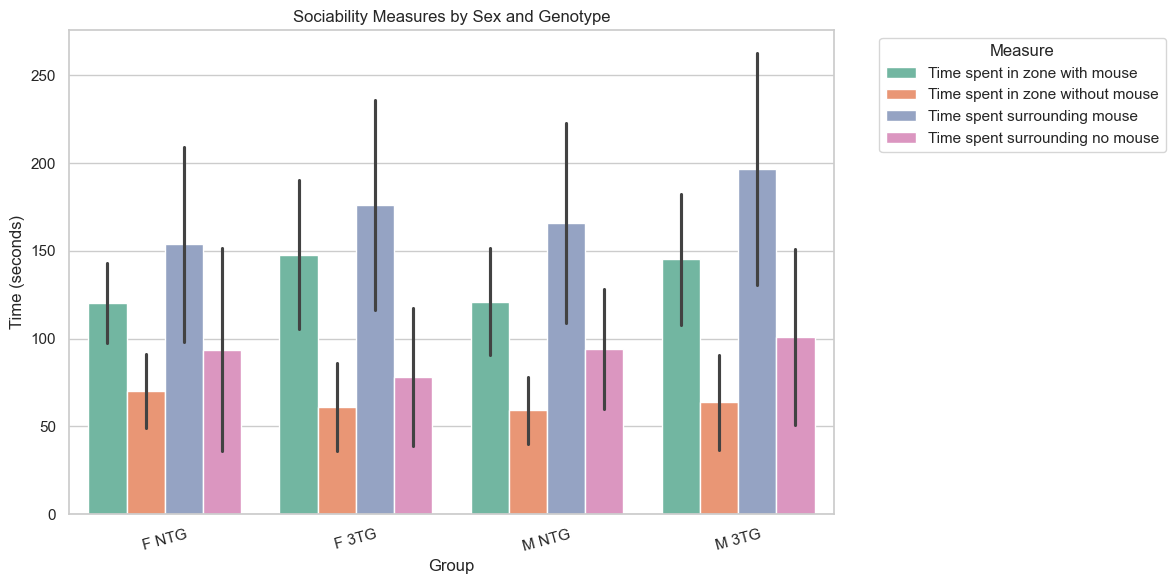

In [84]:
melted_group = prep_soc_measures_for_plotting(etho_3c_sociability_df)
create_plot_sociability_measures(melted_group, OUTPUT_DIR)

### 4.2 Plot mouse in zone with mouse vs without mouse 

In [85]:
def prep_in_zone_plots(df):
    """
    Prepare time spent in the with-mouse and without-mouse zones for plotting.

    Parameters:
    ### df [pandas.DataFrame]: DataFrame containing metadata and zone time measures for each mouse.

    Returns:
    ### df [pandas.DataFrame]: Long-format dataframe with group, measure, and time columns.
    """

    df = df.copy()
    # Combine Sex and Genotype into one column for grouping
    df['Group'] = df['Sex'].astype(str).str.capitalize() + ' ' + df['Genotype'].astype(str)

    # Select only the relevant columns
    cols_to_plot = [
        'Time spent in zone with mouse',
        'Time spent in zone without mouse'
    ]
    # Ensure values are numeric
    df[cols_to_plot] = df[cols_to_plot].apply(pd.to_numeric, errors="coerce")
    
    # Melt the data
    df = pd.melt(
        df,
        id_vars=['Group'],
        value_vars=cols_to_plot,
        var_name='Measure',
        value_name='Time'
    )

    return df

def plot_zones(df, output_dir):
    """
    Plot time spent in the with-mouse and without-mouse zones by group.

    Parameters:
    ### df [pandas.DataFrame]: Long-format dataframe containing group labels, time measures, and time values.

    Returns:
    ### None: Displays + saves the plot.
    """
    # Set style
    sns.set(style="whitegrid")

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df,
        x='Group', 
        y='Time', 
        hue='Measure',
        errorbar='sd', 
        palette='Set1',
        order=["F NTG", "F 3TG", "M NTG", "M 3TG"]
    )
    plt.title('Time Spent in Zone With vs. Without Mouse by Group')
    plt.ylabel('Time (seconds)')
    plt.xlabel('Group')
    plt.xticks(rotation=15)
    plt.legend(title='Measure', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # save plot 
    file_path_plot = os.path.join(output_dir, "day2_time_in_zone_with_vs_without_by_group")
    plt.savefig(file_path_plot)
    
    # show plot 
    plt.show()


### 4.3. Generate in zone plots

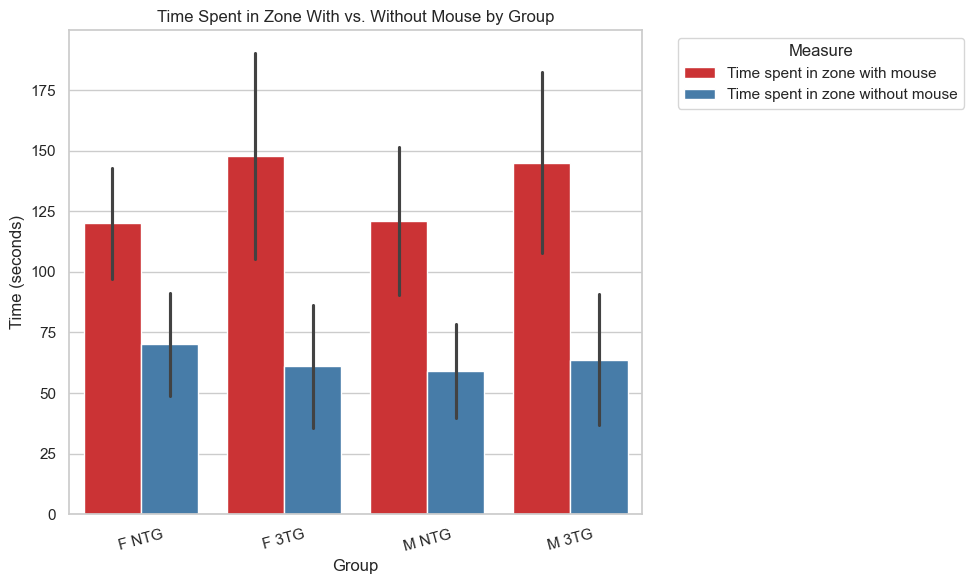

In [22]:
melted_mouse_zone = prep_in_zone_plots(etho_3c_sociability_df)
plot_zones(melted_mouse_zone, OUTPUT_DIR)

### 4.4. Calculate average time spent in zone for each group

With mouse (social) cup

In [24]:
FNTg_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with mouse']
F3Tg_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with mouse']
MNTg_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with mouse']
M3Tg_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with mouse']

/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/186082748.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  FNTg_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/186082748.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  F3Tg_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone with mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/186082748.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  MNTg_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone with mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/186082748.py:4: UserWarning: Boolean S

In [25]:
avg_with_mouse = [FNTg_mouse_zone['Time'].mean(), F3Tg_mouse_zone['Time'].mean(), MNTg_mouse_zone['Time'].mean(), M3Tg_mouse_zone['Time'].mean()]
print("average time spent investigating with mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg):", avg_with_mouse)

mouse_zone_errors = [
    FNTg_mouse_zone['Time'].std(ddof=1) / np.sqrt(FNTg_mouse_zone['Time'].count()),
    F3Tg_mouse_zone['Time'].std(ddof=1) / np.sqrt(F3Tg_mouse_zone['Time'].count()),
    MNTg_mouse_zone['Time'].std(ddof=1) / np.sqrt(MNTg_mouse_zone['Time'].count()),
    M3Tg_mouse_zone['Time'].std(ddof=1) / np.sqrt(M3Tg_mouse_zone['Time'].count())
]
print("standard errors for average time spent with mouse (f Ntg, f 3xTg, m Ntg, m 3xTg):", mouse_zone_errors)

average time spent investigating with mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg): [120.15757575757576, 147.76666666666668, 121.0878787878788, 145.20277777777775]
standard errors for average time spent with mouse (f Ntg, f 3xTg, m Ntg, m 3xTg): [6.918026651122284, 12.817376935830183, 9.169599831246588, 10.773733067714547]


Results 
Average time spent investigating social cup: 
- **f Ntg**: 120.16 ± 6.92
- **f 3xTg**: 147.77 ± 12.82
- **m Ntg**: 121.09 ± 9.17
- **m 3xTg**: 145.21 ± 10.77

Without mouse (non-social) cup

In [27]:
FNTg_no_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone without mouse']
F3Tg_no_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone without mouse']
MNTg_no_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone without mouse']
M3Tg_no_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone without mouse']

/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/3423805251.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  FNTg_no_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone without mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/3423805251.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  F3Tg_no_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'F 3TG'][melted_mouse_zone['Measure'] == 'Time spent in zone without mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/3423805251.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  MNTg_no_mouse_zone = melted_mouse_zone[melted_mouse_zone['Group'] == 'M NTG'][melted_mouse_zone['Measure'] == 'Time spent in zone without mouse']
/var/folders/ck/mbvys3ts22n6lxrjhd0ysvbw0000gn/T/ipykernel_63254/3423805251.py:4: 

In [31]:
avg_without_mouse = [FNTg_no_mouse_zone['Time'].mean(), F3Tg_no_mouse_zone['Time'].mean(), MNTg_no_mouse_zone['Time'].mean(), M3Tg_no_mouse_zone['Time'].mean()]
print("average time spent investigating without mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg):", avg_without_mouse)

no_mouse_zone_errors = [
    FNTg_no_mouse_zone['Time'].std(ddof=1) / np.sqrt(FNTg_no_mouse_zone['Time'].count()),
    F3Tg_no_mouse_zone['Time'].std(ddof=1) / np.sqrt(F3Tg_no_mouse_zone['Time'].count()),
    MNTg_no_mouse_zone['Time'].std(ddof=1) / np.sqrt(MNTg_no_mouse_zone['Time'].count()),
    M3Tg_no_mouse_zone['Time'].std(ddof=1) / np.sqrt(M3Tg_no_mouse_zone['Time'].count())
]
print("standard errors for average time spent without mouse (f Ntg, f 3xTg, m Ntg, m 3xTg):", no_mouse_zone_errors)

average time spent investigating without mouse cup (f Ntg, f 3xTg, m Ntg, m 3xTg): [70.15151515151514, 60.9969696969697, 59.03333333333333, 63.75277777777777]
standard errors for average time spent without mouse (f Ntg, f 3xTg, m Ntg, m 3xTg): [6.4187200392405925, 7.62440321167838, 5.815588595066772, 7.788382155809912]


Results verage time spent investigating non-social cup: 
- **f Ntg**: 70.15 ± 6.42
- **f 3xTg**: 61.00 ± 7.62
- **m Ntg**: 59.03 ± 5.82
- **m 3xTg**: 63.75 ± 7.79

## 5. Calculate a discrimination index for each mouse

In [42]:
# Calculate total investigation time + discrimination index for each mouse and add to the dataframe 
etho_3c_sociability_df = add_derived_measures(etho_3c_sociability_df)

# Save 
output_file = os.path.join(OUTPUT_DIR, 'day2_results_with_index.xlsx')
etho_3c_sociability_df.to_excel(output_file, index=False)

# Define each group subset
FNTg_subset = etho_3c_sociability_df[etho_3c_sociability_df['Group'] == 'F NTG']
F3Tg_subset = etho_3c_sociability_df[etho_3c_sociability_df['Group'] == 'F 3TG']
MNTg_subset = etho_3c_sociability_df[etho_3c_sociability_df['Group'] == 'M NTG']
M3Tg_subset = etho_3c_sociability_df[etho_3c_sociability_df['Group'] == 'M 3TG']


## 6. Calculate average discrimination index

In [43]:
# Calculate the average discrimination index for each genotype
average_sociability_index = [FNTg_subset['discrimination index'].mean(), F3Tg_subset['discrimination index'].mean(), MNTg_subset['discrimination index'].mean(), M3Tg_subset['discrimination index'].mean()]
print('Average sociability index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', average_sociability_index)

# Calculate SEM error bars 
sociability_errors = [
    FNTg_subset['discrimination index'].std(ddof=1) / np.sqrt(FNTg_subset['discrimination index'].count()),
    F3Tg_subset['discrimination index'].std(ddof=1) / np.sqrt(F3Tg_subset['discrimination index'].count()),
    MNTg_subset['discrimination index'].std(ddof=1) / np.sqrt(MNTg_subset['discrimination index'].count()),
    M3Tg_subset['discrimination index'].std(ddof=1) / np.sqrt(M3Tg_subset['discrimination index'].count())
]
print('SEM of sociability index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', sociability_errors)

# Calculate the average total investigation time for each genotype
average_total_investigation_time = [FNTg_subset['total investigation time'].mean(), F3Tg_subset['total investigation time'].mean(), MNTg_subset['total investigation time'].mean(), M3Tg_subset['total investigation time'].mean()]
print('Average total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', average_total_investigation_time)

# Calculate SEM error bars 
investigation_time_errors = [
    FNTg_subset['total investigation time'].std(ddof=1) / np.sqrt(FNTg_subset['total investigation time'].count()),
    F3Tg_subset['total investigation time'].std(ddof=1) / np.sqrt(F3Tg_subset['total investigation time'].count()),
    MNTg_subset['total investigation time'].std(ddof=1) / np.sqrt(MNTg_subset['total investigation time'].count()),
    M3Tg_subset['total investigation time'].std(ddof=1) / np.sqrt(M3Tg_subset['total investigation time'].count())
]
print('SEM of total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg', investigation_time_errors)

Average sociability index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [0.27273366925762416, 0.3956232407168921, 0.3490414690927, 0.39603051259389505]
SEM of sociability index for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [0.04841705512737791, 0.09047864939118172, 0.041210658413218186, 0.05825882656426817]
Average total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [190.30909090909088, 208.76363636363638, 180.12121212121212, 208.95555555555555]
SEM of total investigation time for each group (f Ntg, f 3xTg, m Ntg, m 3xTg [10.42404377893887, 8.316499912757655, 13.030148624877985, 12.562765204553346]


Results for average sociability index
- **f Ntg**: 0.27 ± 0.05
- **f 3xTg**: 0.40 ± 0.09
- **m Ntg**: 0.35 ± 0.04
- **m 3xTg**: 0.40 ± 0.06

Results for average total investigation time 
- **f Ntg**: 190.31 ± 10.42
- **f 3xTg**: 208.77 ± 8.32 
- **m Ntg**: 180.12 ± 12.03
- **m 3xTg**: 208.96 ± 12.56

Average for the 3xTg mice 

In [35]:
trans_subset = etho_3c_sociability_df[etho_3c_sociability_df['Genotype'] == '3TG']
avg_trans_index = trans_subset['discrimination index'].mean()
print("average discrimination index for 3xTg", avg_trans_index)
trans_error_di= trans_subset['discrimination index'].std(ddof=1) / np.sqrt(trans_subset['discrimination index'].count())
print("SEM of discrimination index for 3xTg", trans_error_di)

average discrimination index for 3xTg 0.3958357303918502
SEM of discrimination index for 3xTg 0.051624277438745564


Average for control mice

In [37]:
control_subset = etho_3c_sociability_df[etho_3c_sociability_df['Genotype'] == 'NTG']
avg_control_index = control_subset['discrimination index'].mean()
print("average discrimination index for Ntg (control):", avg_control_index)
control_error_di= control_subset['discrimination index'].std(ddof=1) / np.sqrt(control_subset['discrimination index'].count())
print("SEM of discrimination index for Ntg (control):", control_error_di)

average discrimination index for Ntg (control): 0.31088756917516214
SEM of discrimination index for Ntg (control): 0.032122064845871615


Average total investigation time for 3xTg vs Ntg

In [40]:
# 3xTg
avg_trans_tit = trans_subset['total investigation time'].mean()
print("Average total investigation time for 3xTg:", avg_trans_tit)
trans_error_tit= trans_subset['total investigation time'].std(ddof=1) / np.sqrt(trans_subset['total investigation time'].count())
print("SEM of total investigation time for 3xTg:", trans_error_tit)

# Ntg
avg_control_tit = control_subset['total investigation time'].mean()
print("Average total investigation time for Ntg (control):", avg_control_tit)
control_error_tit= control_subset['total investigation time'].std(ddof=1) / np.sqrt(control_subset['total investigation time'].count())
print("SEM of total investigation time for Ntg (control):", control_error_tit)

Average total investigation time for 3xTg: 208.86376811594204
SEM of total investigation time for 3xTg: 7.497155634857685
Average total investigation time for Ntg (control): 185.21515151515152
SEM of total investigation time for Ntg (control): 8.217795811551284


Average investigation time of social cup 3xTg vs control

In [41]:
# 3xTg
trans_social_it = trans_subset['Time spent in zone with mouse'].mean()
trans_social_error= trans_subset['Time spent in zone with mouse'].std(ddof=1) / np.sqrt(trans_subset['Time spent in zone with mouse'].count())
print(f"Average investigation time of social cup for 3xTg: {trans_social_it} ± {trans_social_error}")


# Ntg (control)
control_social_it = control_subset['Time spent in zone with mouse'].mean()
control_social_error= control_subset['Time spent in zone with mouse'].std(ddof=1) / np.sqrt(control_subset['Time spent in zone with mouse'].count())
print(f"Average investigation time of social cup for Ntg (control): {control_social_it} ± {control_social_error}")

Average investigation time of social cup for 3xTg: 146.42898550724635 ± 8.128266663164363
Average investigation time of social cup for Ntg (control): 120.62272727272726 ± 5.605777780393512


## 7. Visualize findings

In [50]:
def plot_si_and_tit(avg_di, di_errors, avg_tit, tit_errors, output_dir): 
    """
    Plot average sociability index and total investigation time by group.

    Parameters:
    ### avg_di [list]: Average discrimination index values for each group.
    ### di_errors list]: Error values for the discrimination index bars.
    ### avg_tit [list]: Average total investigation time values for each group.
    ### tit_errors [list]: Error values for the total investigation time bars.
    ### output_dir [str]: Directory where the plot should be saved.

    Returns:
    ### None: function saves and shows plot
    """
    groups = ["F NTG", "F 3TG", "M NTG", "M 3TG"]
    colors = ["#A991D4", "#7AC5CD", "#FDB462", "#8DD3C7"] # lilac, turquoise, soft orange, soft green

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].bar(
        groups,
        avg_di,
        yerr=di_errors,
        capsize=5,
        color=colors,
    )
    axes[0].set_xlabel("Genotype & Sex")
    axes[0].set_ylabel("Average discrimination index")
    axes[0].set_title("Discrimination index - Day 2")

    axes[1].bar(
        groups,
        avg_tit,
        yerr=tit_errors,
        capsize=5,
        color=colors,
    )
    axes[1].set_xlabel("Genotype & Sex")
    axes[1].set_ylabel("Average total investigation time")
    axes[1].set_title("Total investigation time - Day 2")

    plt.tight_layout()

    file_path_plot = os.path.join(
        output_dir,
        "day2_sociability_index_and_total_investigation_time",
    )

    plt.savefig(file_path_plot)
    plt.show()
    plt.close()

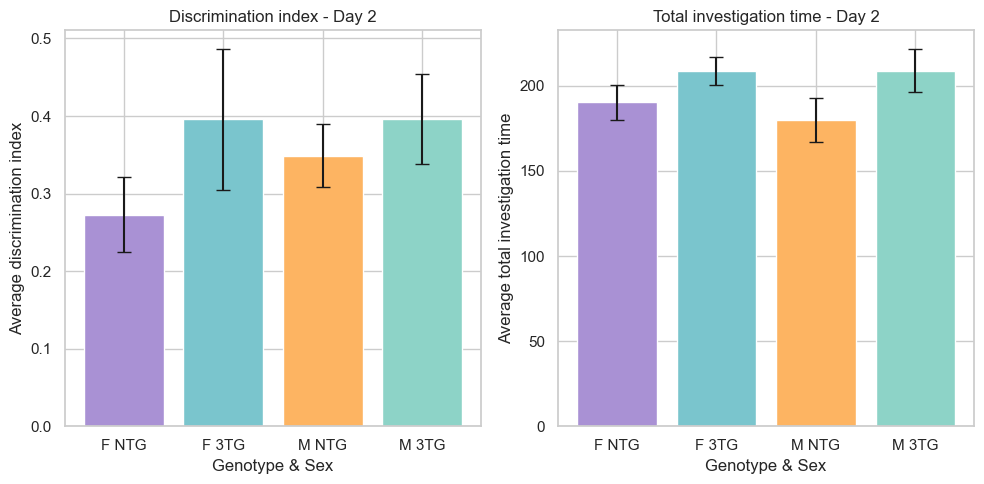

In [51]:
plot_si_and_tit(average_sociability_index, sociability_errors, average_total_investigation_time, investigation_time_errors, OUTPUT_DIR)

## 8. Perform statistical analyses

### 8.1. Inspect group sizes 

In [52]:
display(etho_3c_sociability_df.groupby("Group").size().rename("n").reset_index())

,Group,n
0,F 3TG,11
1,F NTG,11
2,M 3TG,12
3,M NTG,11


### 8.2. Check statistical assumptions for discrimination index

#### 8.2.1. Test normality using Shapiro-Wilk test

In [61]:
for group, subset in etho_3c_sociability_df.groupby(["Genotype", "Sex"]):
    stat, p = stats.shapiro(subset["discrimination index"])
    print(group, p)

('3TG', 'F') 0.6071796004954353
('3TG', 'M') 0.19183664666731448
('NTG', 'F') 0.6280545092572141
('NTG', 'M') 0.6821917632772203


All groups were normally distributed according to the Shapiro-Wilk test, as all p-values were greater than 0.05.

##### QQ plots

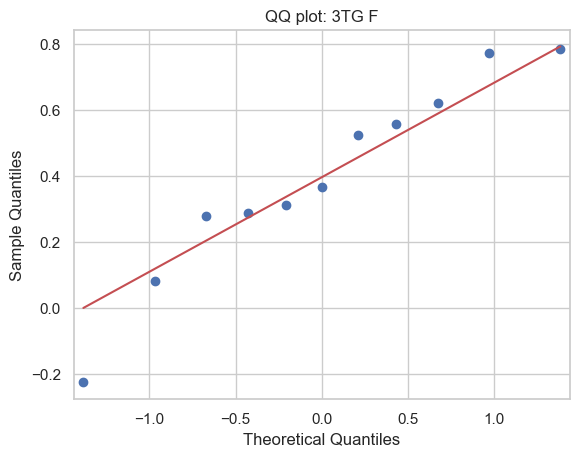

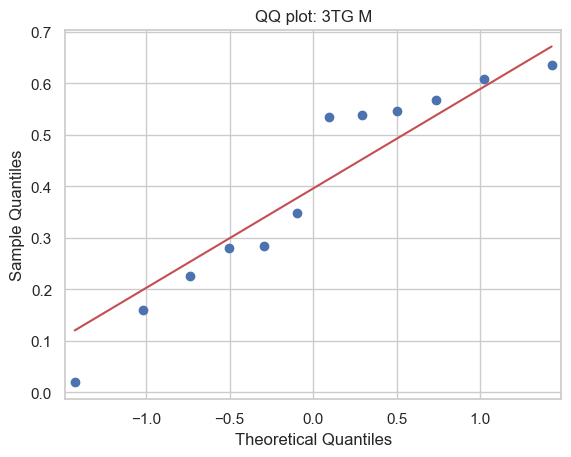

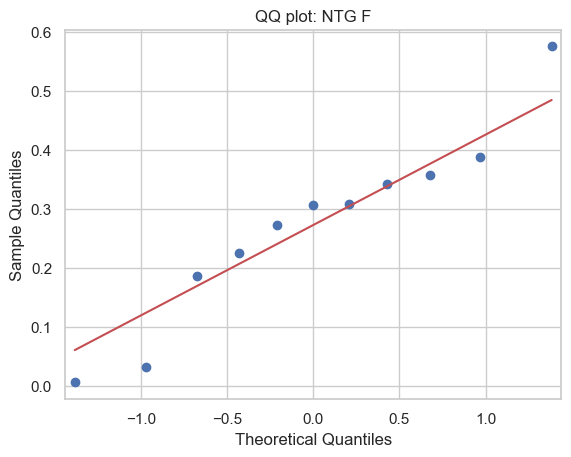

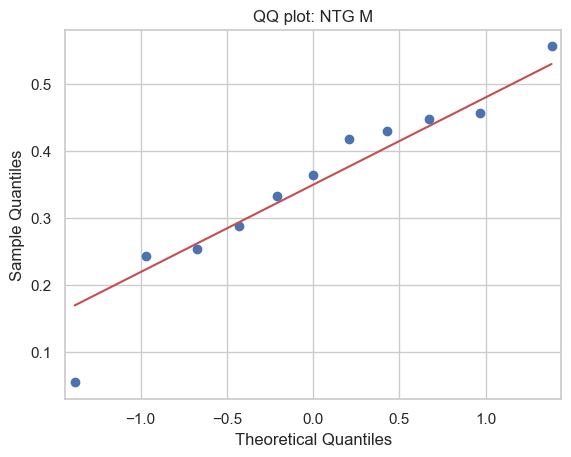

In [65]:
groups = etho_3c_sociability_df.groupby(["Genotype", "Sex"])

for (genotype, sex), subset in groups:
    data = subset["discrimination index"].dropna()

    sm.qqplot(data, line="s")
    plt.title(f"QQ plot: {genotype} {sex}")
    file_path_plot = os.path.join(OUTPUT_DIR, f"qq plots day2 DI {genotype} {sex}")
    plt.savefig(file_path_plot)
    plt.show()

#### 8.2.2. Test homogeneity of variance using Levene's test

In [63]:
stats.levene(
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="NTG") & (etho_3c_sociability_df.Sex=="M")]["discrimination index"],
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="NTG") & (etho_3c_sociability_df.Sex=="F")]["discrimination index"],
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="3TG") & (etho_3c_sociability_df.Sex=="M")]["discrimination index"],
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="3TG") & (etho_3c_sociability_df.Sex=="F")]["discrimination index"]
)

LeveneResult(statistic=2.459639860142711, pvalue=0.07629533392516136)

The assumption of equal variances was met according to Levene’s test, as p > 0.05.

### 8.2. Perform two-way ANOVA on discrimination index 

In [70]:
model_di = smf.ols("Q('discrimination index') ~ C(Genotype) * C(Sex)", data=etho_3c_sociability_df).fit()
anova_table_di = sm.stats.anova_lm(model_di, typ=2)

print(anova_table_di)

                      sum_sq    df         F    PR(>F)
C(Genotype)         0.079552   1.0  1.818899  0.184847
C(Sex)              0.015847   1.0  0.362334  0.550527
C(Genotype):C(Sex)  0.016180   1.0  0.369931  0.546397
Residual            1.793201  41.0       NaN       NaN


Results show now significant differences 

### 8.3. Check statistical assumptions for total investigation time

#### 8.3.1. Test normality using Shapiro-Wilk test

In [66]:
for group, subset in etho_3c_sociability_df.groupby(["Genotype", "Sex"]):
    stat, p = stats.shapiro(subset["total investigation time"])
    print(group, p)

('3TG', 'F') 0.8906167050368462
('3TG', 'M') 0.6380864473889689
('NTG', 'F') 0.39743010920803584
('NTG', 'M') 0.6695609609099282


All groups were normally distributed according to the Shapiro-Wilk test, as all p-values were greater than 0.05.

##### QQ plots

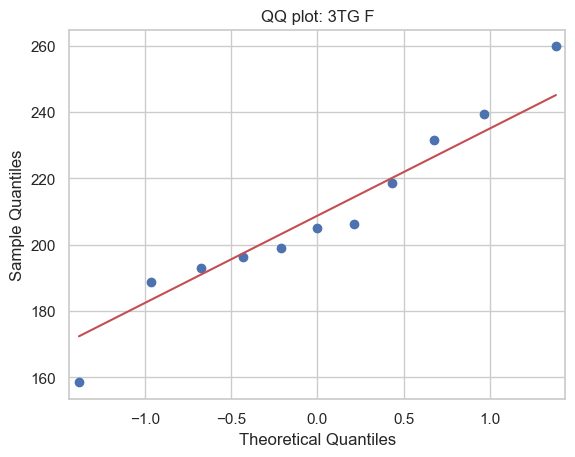

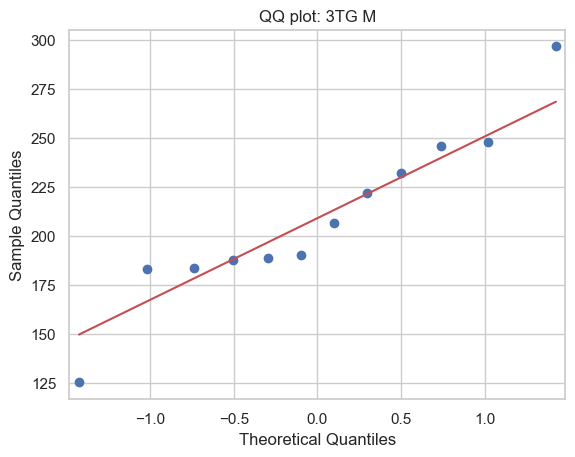

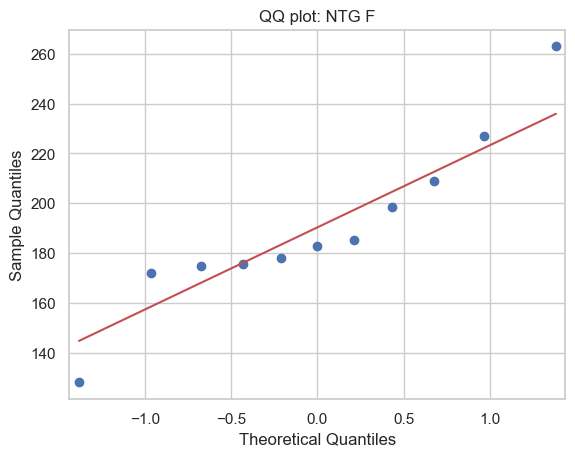

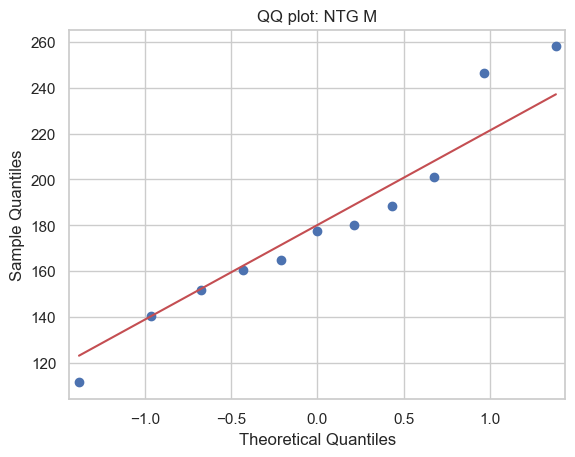

In [69]:
groups = etho_3c_sociability_df.groupby(["Genotype", "Sex"])

for (genotype, sex), subset in groups:
    data = subset["total investigation time"].dropna()

    sm.qqplot(data, line="s")
    plt.title(f"QQ plot: {genotype} {sex}")
    file_path_plot = os.path.join(OUTPUT_DIR, f"qq plots d2 {genotype} {sex} tit")
    plt.savefig(file_path_plot)
    plt.show()

#### 8.3.2. Check homogeneity of variance using Levene's test

In [67]:
# Levene 
stats.levene(
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="NTG") & (etho_3c_sociability_df.Sex=="M")]["total investigation time"],
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="NTG") & (etho_3c_sociability_df.Sex=="F")]["total investigation time"],
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="3TG") & (etho_3c_sociability_df.Sex=="M")]["total investigation time"],
    etho_3c_sociability_df[(etho_3c_sociability_df.Genotype=="3TG") & (etho_3c_sociability_df.Sex=="F")]["total investigation time"]
)

LeveneResult(statistic=0.6492490708563071, pvalue=0.5879531844654936)

The assumption of equal variances was met according to Levene’s test, as p > 0.05.

### 8.3. Perform two-way ANOVA on total investigation time

In [72]:
model_tit = smf.ols("Q('total investigation time') ~ C(Genotype) * C(Sex)", 
    data=etho_3c_sociability_df
).fit()
anova_table_tit = sm.stats.anova_lm(model_tit, typ=2)

print(anova_table_tit)


                          sum_sq    df         F    PR(>F)
C(Genotype)          6342.171009   1.0  4.402071  0.042100
C(Sex)                268.482682   1.0  0.186353  0.668232
C(Genotype):C(Sex)    302.589515   1.0  0.210026  0.649167
Residual            59069.704781  41.0       NaN       NaN


A significant difference in total investigation time between genotypes is found.
Next step is to check whether this is driven by significant differences in investigation of social and/or non-social cup. 

### 8.4. Perform two-way ANOVA on investigation time of each cup

#### 8.4.1. Social cup investigation

In [74]:
model_with_mouse = smf.ols(
    'Q("Time spent in zone with mouse") ~ C(Genotype) * C(Sex)',
    data=etho_3c_sociability_df
).fit()
anova_table_with_mouse = sm.stats.anova_lm(model_with_mouse, typ=2)

print(anova_table_with_mouse)

                          sum_sq    df         F    PR(>F)
C(Genotype)          7495.617360   1.0  6.415000  0.015239
C(Sex)                  8.196209   1.0  0.007015  0.933660
C(Genotype):C(Sex)     34.290166   1.0  0.029347  0.864824
Residual            47906.517382  41.0       NaN       NaN


There is a significant difference in investigation time of the social cup between Genotypes. 

#### 8.4.2. Non-social cup investigation

In [75]:
model_nomouse = smf.ols(
    'Q("Time spent in zone without mouse") ~ C(Genotype) * C(Sex)',
    data=etho_3c_sociability_df
).fit()
anova_table_no_mouse = sm.stats.anova_lm(model_nomouse, typ=2)

print(anova_table_no_mouse)

                          sum_sq    df         F    PR(>F)
C(Genotype)            48.156450   1.0  0.087156  0.769314
C(Sex)                182.859059   1.0  0.330948  0.568245
C(Genotype):C(Sex)    540.603460   1.0  0.978414  0.328393
Residual            22653.756170  41.0       NaN       NaN


There is a not a significant difference in investigation time of the non-social cup between Genotypes, sex or their interaction. 

### 8.5. Calculate effect sizes

#### 8.5.1. Of the discrimination index

In [78]:
# DI
anova_di = sm.stats.anova_lm(model_di, typ=2)

ss_res = anova_di.loc["Residual", "sum_sq"]

anova_di["partial_eta_sq"] = (
    anova_di["sum_sq"] /
    (anova_di["sum_sq"] + ss_res)
)

anova_di["partial_eta_sq"] = np.nan

ss_res = anova_di.loc["Residual", "sum_sq"]

for effect in ["C(Genotype)", "C(Sex)", "C(Genotype):C(Sex)"]:
    anova_di.loc[effect, "partial_eta_sq"] = (
        anova_di.loc[effect, "sum_sq"] /
        (anova_di.loc[effect, "sum_sq"] + ss_res)
    )

print("discrimination index")
print(anova_di)

discrimination index
                      sum_sq    df         F    PR(>F)  partial_eta_sq
C(Genotype)         0.079552   1.0  1.818899  0.184847        0.042479
C(Sex)              0.015847   1.0  0.362334  0.550527        0.008760
C(Genotype):C(Sex)  0.016180   1.0  0.369931  0.546397        0.008942
Residual            1.793201  41.0       NaN       NaN             NaN


#### 8.5.2. Of total investigation time

In [79]:
# total investigation time 
anova_tit = sm.stats.anova_lm(model_tit, typ=2)

ss_res = anova_tit.loc["Residual", "sum_sq"]

anova_tit["partial_eta_sq"] = (
    anova_tit["sum_sq"] /
    (anova_tit["sum_sq"] + ss_res)
)

anova_tit["partial_eta_sq"] = np.nan

ss_res = anova_tit.loc["Residual", "sum_sq"]

for effect in ["C(Genotype)", "C(Sex)", "C(Genotype):C(Sex)"]:
    anova_tit.loc[effect, "partial_eta_sq"] = (
        anova_tit.loc[effect, "sum_sq"] /
        (anova_tit.loc[effect, "sum_sq"] + ss_res)
    )


print("total investigation time:")
print(anova_tit)

total investigation time:
                          sum_sq    df         F    PR(>F)  partial_eta_sq
C(Genotype)          6342.171009   1.0  4.402071  0.042100        0.096957
C(Sex)                268.482682   1.0  0.186353  0.668232        0.004525
C(Genotype):C(Sex)    302.589515   1.0  0.210026  0.649167        0.005096
Residual            59069.704781  41.0       NaN       NaN             NaN


#### 8.5.3. Of social cup investigation time

In [81]:
# with mouse investigation 
anova_with_mouse = sm.stats.anova_lm(model_with_mouse, typ=2)

ss_res = anova_with_mouse.loc["Residual", "sum_sq"]

anova_with_mouse["partial_eta_sq"] = (
    anova_with_mouse["sum_sq"] /
    (anova_with_mouse["sum_sq"] + ss_res)
)

anova_with_mouse["partial_eta_sq"] = np.nan

ss_res = anova_with_mouse.loc["Residual", "sum_sq"]

for effect in ["C(Genotype)", "C(Sex)", "C(Genotype):C(Sex)"]:
    anova_with_mouse.loc[effect, "partial_eta_sq"] = (
        anova_with_mouse.loc[effect, "sum_sq"] /
        (anova_with_mouse.loc[effect, "sum_sq"] + ss_res)
    )


print("social cup investigation time:")
print(anova_with_mouse)

social cup investigation time:
                          sum_sq    df         F    PR(>F)  partial_eta_sq
C(Genotype)          7495.617360   1.0  6.415000  0.015239        0.135295
C(Sex)                  8.196209   1.0  0.007015  0.933660        0.000171
C(Genotype):C(Sex)     34.290166   1.0  0.029347  0.864824        0.000715
Residual            47906.517382  41.0       NaN       NaN             NaN
